# 4. Training a CNN
**Data Mining & ML 2 — Prof. Dr. Patrick Baier — SS 26**

In this notebook we train a small CNN on the MNIST dataset and compare it to the Logistic Regression baseline from Chapter 1.

**What you will do:**
1. Load and prepare MNIST with PyTorch's `torchvision`
2. Define a simple CNN in PyTorch
3. Train it and evaluate the accuracy
4. Extend the architecture in several steps
5. Compare the result to Logistic Regression

---
## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

torch.manual_seed(0)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


---
## 2. Load Data

We use `torchvision` to load MNIST directly — no sklearn needed this time.

Note: unlike last week, the images are **not** flattened to 784 values.
They stay as `(1, 28, 28)` tensors — one grayscale channel, 28×28 pixels.
This is exactly the format a CNN expects.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),                        # converts PIL image to (1, 28, 28) float tensor
    transforms.Normalize((0.1307,), (0.3081,))    # normalize: (pixel - mean) / std
])

train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")

# Inspect one batch
images, labels = next(iter(train_loader))
print(f"Batch shape      : {images.shape}   → (batch, channels, H, W)")

Training samples : 60,000
Test samples     : 10,000
Batch shape      : torch.Size([64, 1, 28, 28])   → (batch, channels, H, W)


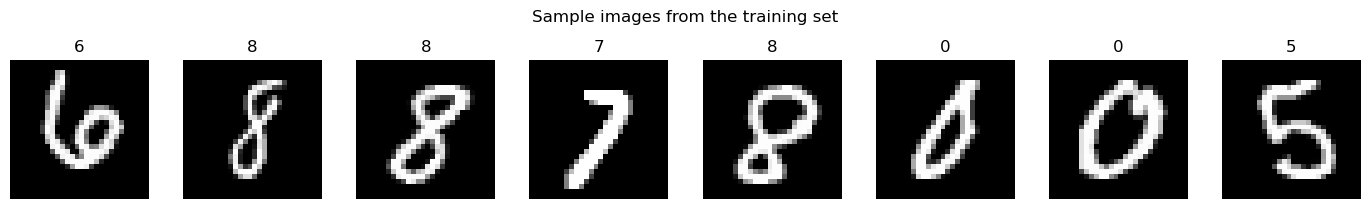

In [3]:
# Visualize a few samples
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(str(labels[i].item()))
    ax.axis('off')
plt.suptitle('Sample images from the training set', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Define the CNN

We start with a small network:
- 1 convolutional layer (4 filters, 3×3 kernel) followed by ReLU and MaxPool
- 1 fully connected output layer (10 classes)

**Dimension trace** (with input `1×28×28`):

| Step | Formula | Output shape |
|---|---|---|
| Conv2d(1, 4, kernel=3, padding=0) | (28 - 3 + 1) = 26 | `4×26×26` |
| ReLU | — | `4×26×26` |
| MaxPool2d(2, stride=2) | 26 // 2 = 13 | `4×13×13` |
| Flatten | 4 × 13 × 13 | `676` |
| Linear(676, 10) | — | `10` |

In [4]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=3)  # 1×28×28 → 4×26×26
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)                    # → 4×13×13
        self.fc    = nn.Linear(4 * 13 * 13, 10)                               # → 10 classes

    def forward(self, x):
        x = F.relu(self.conv1(x))   # conv + ReLU
        x = self.pool(x)            # max pooling
        x = torch.flatten(x, 1)     # flatten all dims except batch
        x = self.fc(x)              # output logits (no softmax — CrossEntropyLoss handles it)
        return x

model = CNN()
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

CNN(
  (conv1): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=676, out_features=10, bias=True)
)

Total parameters: 6,810


---
## 4. Train and Evaluate

We use:
- **Loss:** `CrossEntropyLoss` — this is the log-loss from the lecture, softmax is applied internally
- **Optimizer:** `Adam` — an improved version of SGD that adapts the learning rate automatically
- **Mini-batch training** via `DataLoader` — instead of computing the gradient on all 60,000 samples at once (batch GD), we update after every batch of 64 images

In [5]:
def train(model, train_loader, test_loader, epochs=5, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, test_accs = [], []

    for epoch in range(epochs):
        # ── Training ──
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            preds = model(images)
            loss = criterion(preds, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        avg_loss = running_loss / len(train_loader.dataset)
        train_losses.append(avg_loss)

        # ── Evaluation ──
        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                preds = torch.argmax(model(images), dim=1)
                correct += (preds == labels).sum().item()

        acc = correct / len(test_loader.dataset)
        test_accs.append(acc)
        print(f"Epoch {epoch+1}/{epochs}  Loss: {avg_loss:.4f}  Test accuracy: {acc*100:.2f}%")

    return train_losses, test_accs


def plot_training(train_losses, test_accs):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(range(1, len(train_losses)+1), train_losses, 'o-', color='steelblue')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

    axes[1].plot(range(1, len(test_accs)+1), [a*100 for a in test_accs], 'o-', color='tomato')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Test Accuracy'); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Epoch 1/5  Loss: 0.3470  Test accuracy: 95.23%
Epoch 2/5  Loss: 0.1432  Test accuracy: 96.49%
Epoch 3/5  Loss: 0.1102  Test accuracy: 96.94%
Epoch 4/5  Loss: 0.0973  Test accuracy: 97.24%
Epoch 5/5  Loss: 0.0895  Test accuracy: 97.30%


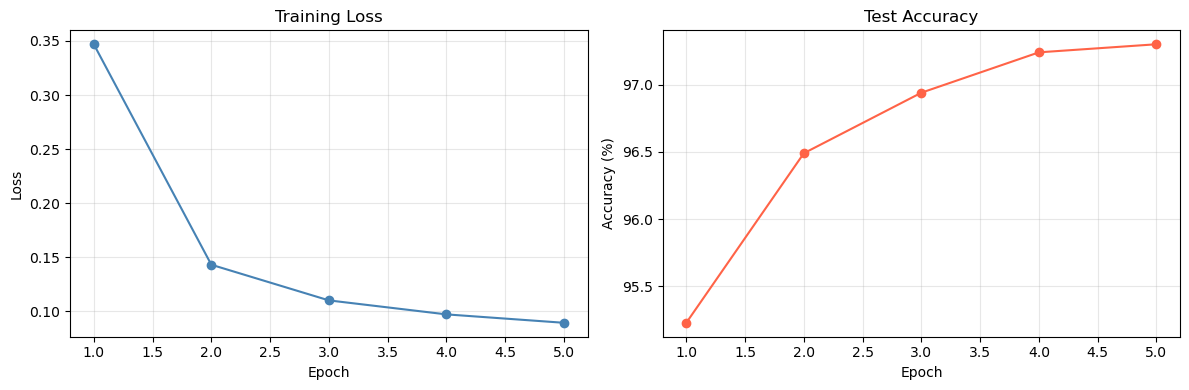

In [6]:
cnn = CNN()
losses, accs = train(cnn, train_loader, test_loader, epochs=5)
plot_training(losses, accs)

---
## 5. Coding Tasks

Extend the CNN step by step. After each change, retrain the model and note the test accuracy.

**Keep track of your results here:**

| Version | Architecture change | Test accuracy |
|---|---|---|
| Baseline | Conv(4, k=3) → Pool → FC(10) | ? % |
| Task 1 | kernel_size=5, padding=1 | ? % |
| Task 2 | + second Conv layer | ? % |
| Task 3 | + second FC layer | ? % |

### Task 1 — Understand the flattened size

In the baseline CNN, the fully connected layer is defined as `nn.Linear(4 * 13 * 13, 10)`.

**Answer the following questions in the cell below:**
- Where does the `4` come from?
- Where does the `13` come from? Trace it step by step using the formula: $\text{output} = \lfloor(\text{input-size} + 2p - k) / s\rfloor + 1$, where $p$ is padding, $k$ is kernel size and $s$ is stride. 
- What would the flattened size be if you changed `kernel_size` to 5 and added `padding=1`?

In [7]:
# Use this cell to calculate the new flattened size
def conv_out(input_size, kernel_size, padding=0, stride=1):
    return (input_size + 2 * padding - kernel_size) // stride + 1

# Baseline:
after_conv1 = conv_out(28, kernel_size=3, padding=0)
after_pool1 = conv_out(after_conv1, kernel_size=2, stride=2)
print(f"Baseline → after Conv1: {after_conv1}, after Pool1: {after_pool1}, flattened: 4×{after_pool1}×{after_pool1} = {4*after_pool1*after_pool1}")

# Task 1: kernel_size=5, padding=1 — fill in the values:
after_conv1_new = conv_out(28, kernel_size=5, padding=1)
after_pool1_new = conv_out(after_conv1_new, kernel_size=2, stride=2)
print(f"Task 1  → after Conv1: {after_conv1_new}, after Pool1: {after_pool1_new}, flattened: 4×{after_pool1_new}×{after_pool1_new} = {4*after_pool1_new*after_pool1_new}")


Baseline → after Conv1: 26, after Pool1: 13, flattened: 4×13×13 = 676
Task 1  → after Conv1: 26, after Pool1: 13, flattened: 4×13×13 = 676


Now implement it — change `kernel_size` to 5 and add `padding=1`. Don't forget to update the `nn.Linear` input size.

Epoch 1/5  Loss: 0.2738  Test accuracy: 96.48%
Epoch 2/5  Loss: 0.1120  Test accuracy: 96.86%
Epoch 3/5  Loss: 0.0860  Test accuracy: 97.59%
Epoch 4/5  Loss: 0.0740  Test accuracy: 97.71%
Epoch 5/5  Loss: 0.0651  Test accuracy: 97.65%


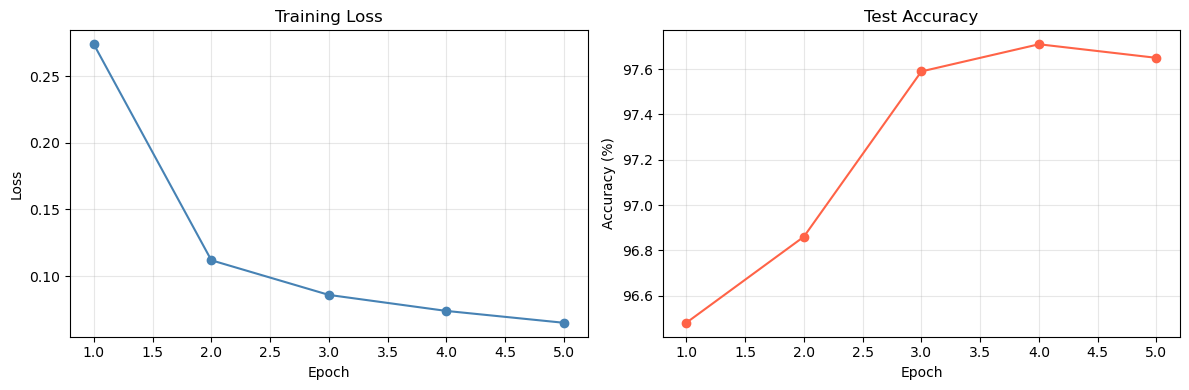

In [8]:
class CNN_v1(nn.Module):
    def __init__(self):
        super(CNN_v1, self).__init__()
        # TODO: change kernel_size to 5 and add padding=1
        self.conv1 = nn.Conv2d(1, 4, kernel_size=5, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        # TODO: update the flattened size here
        self.fc    = nn.Linear(4 * 13 * 13, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

cnn_v1 = CNN_v1()
losses_v1, accs_v1 = train(cnn_v1, train_loader, test_loader, epochs=5)
plot_training(losses_v1, accs_v1)

### Task 2 — Add a second convolutional layer

Add a second Conv layer after the first one, **before** the pooling:
- `kernel_size=3`, `out_channels=8`, `padding=0` for both conv layers
- Only one pooling layer (after both conv layers)

**Hint:** Trace the dimensions carefully before writing the code.

$$28 \xrightarrow{\text{Conv1 k=3, p=0}} ? \xrightarrow{\text{Conv2 k=3, p=0}} ? \xrightarrow{\text{Pool 2×2}} ? \rightarrow \text{flatten} \rightarrow 8 \times ? \times ?$$

Flattened size: 1152
Epoch 1/5  Loss: 0.2276  Test accuracy: 97.27%
Epoch 2/5  Loss: 0.0804  Test accuracy: 97.63%
Epoch 3/5  Loss: 0.0597  Test accuracy: 98.12%
Epoch 4/5  Loss: 0.0496  Test accuracy: 98.37%
Epoch 5/5  Loss: 0.0423  Test accuracy: 97.95%


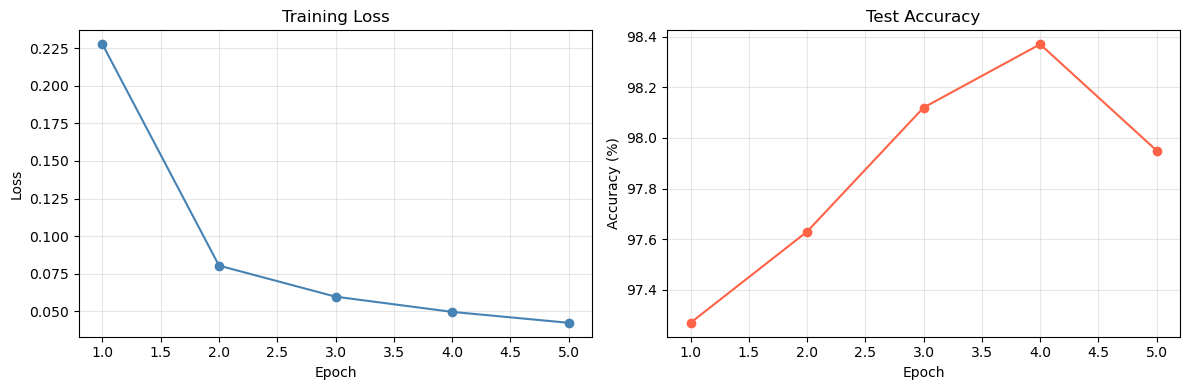

In [9]:
# Calculate the flattened size first:
after_conv1 = conv_out(28, kernel_size=3, padding=0)
after_conv2 = conv_out(after_conv1, kernel_size=3, padding=0)
after_pool  = conv_out(after_conv2, kernel_size=2, stride=2)
flattened   = 8 * after_pool * after_pool
print(f"Flattened size: {flattened}")

class CNN_v2(nn.Module):
    def __init__(self):
        super(CNN_v2, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)
        self.conv2 = nn.Conv2d(8, 8, kernel_size=3)
        self.pool  = nn.MaxPool2d(2, 2)
        # TODO: define fc with correct flattened input size
        self.fc   = nn.Linear(flattened, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

cnn_v2 = CNN_v2()
losses_v2, accs_v2 = train(cnn_v2, train_loader, test_loader, epochs=5)
plot_training(losses_v2, accs_v2)

<details>
<summary>💡 Hint: Dimension calculation (click to expand)</summary>

```python
after_conv1 = conv_out(28, kernel_size=3, padding=0)  # → 26
after_conv2 = conv_out(26, kernel_size=3, padding=0)  # → 24
after_pool  = conv_out(24, kernel_size=2, stride=2)   # → 12
flattened   = 8 * 12 * 12                             # → 1152
```
</details>

### Task 3 — Add a second fully connected layer

Take your best architecture from Task 2 and add a hidden FC layer with **84 neurons** and ReLU activation, just before the output layer.

The classifier head then looks like:
```
Flatten → Linear(flattened, 84) → ReLU → Linear(84, 10)
```

Epoch 1/5  Loss: 0.2083  Test accuracy: 97.28%
Epoch 2/5  Loss: 0.0599  Test accuracy: 98.14%
Epoch 3/5  Loss: 0.0401  Test accuracy: 98.52%
Epoch 4/5  Loss: 0.0309  Test accuracy: 98.77%
Epoch 5/5  Loss: 0.0238  Test accuracy: 98.49%


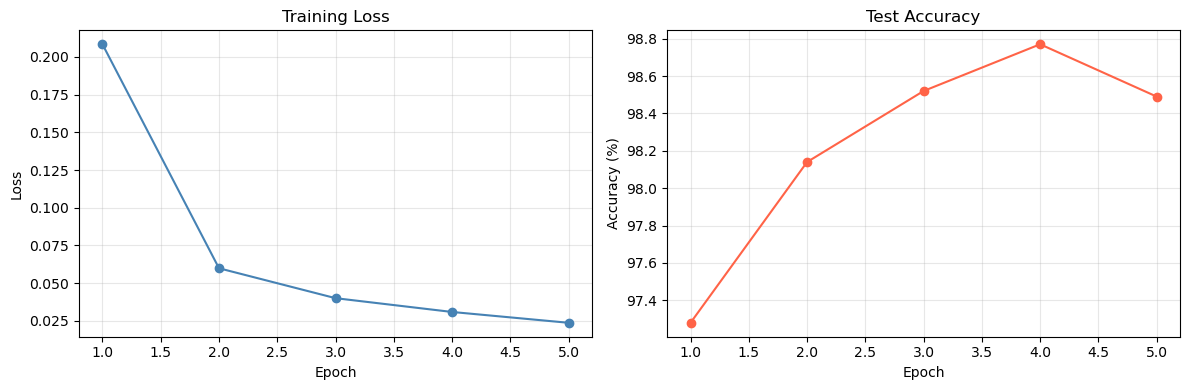

In [10]:
class CNN_v3(nn.Module):
    def __init__(self):
        super(CNN_v3, self).__init__()
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3)
        self.conv2 = nn.Conv2d(8, 8, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(flattened, 84)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cnn_v3 = CNN_v3()
losses_v3, accs_v3 = train(cnn_v3, train_loader, test_loader, epochs=5)
plot_training(losses_v3, accs_v3)

---
## 6. Comparison: CNN vs. Logistic Regression

In Chapter 1 we classified MNIST using Logistic Regression. Let's compare.

Run the cell below to train a Logistic Regression baseline and fill in the results table.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np

# Load flat MNIST (same as Chapter 1)
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, cache=True, parser='auto')
X = (X / 255.0).astype('float32')
y = y.astype('int')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

lr = LogisticRegression(max_iter=100, random_state=42)
lr.fit(X_train, y_train)
lr_acc = lr.score(X_test, y_test)
print(f"Logistic Regression test accuracy: {lr_acc*100:.2f}%")

Logistic Regression test accuracy: 92.10%


/Users/pbaier/miniconda3/envs/dmml2-ss24/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


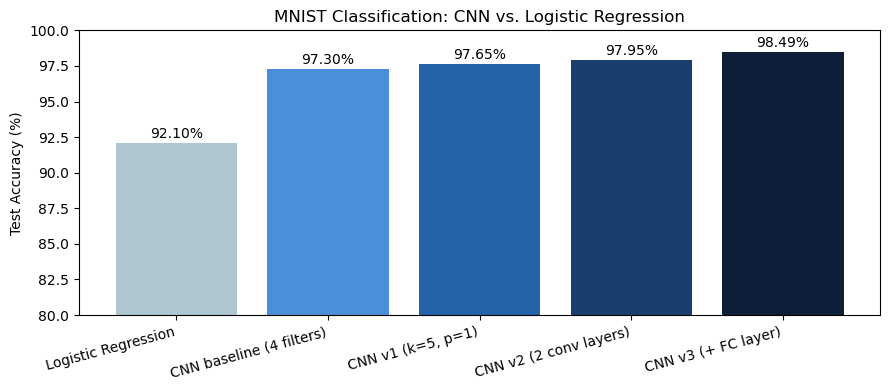

In [12]:
# Fill this in after running all your models:
results = {
    'Logistic Regression': lr_acc * 100,
    'CNN baseline (4 filters)': accs[-1] * 100,
    'CNN v1 (k=5, p=1)':  accs_v1[-1] * 100,
    'CNN v2 (2 conv layers)': accs_v2[-1] * 100,
    'CNN v3 (+ FC layer)': accs_v3[-1] * 100,
}

plt.figure(figsize=(9, 4))
bars = plt.bar(results.keys(), results.values(), color=['#aec6cf', '#4a90d9', '#2563a8', '#1a3f6f', '#0d1f38'][:len(results)])
plt.ylabel('Test Accuracy (%)')
plt.title('MNIST Classification: CNN vs. Logistic Regression')
plt.ylim(80, 100)
for bar, val in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{val:.2f}%',
             ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

### Reflection questions

Answer the following questions briefly:

1. How much better is your best CNN compared to Logistic Regression? What explains this gap?
2. The CNN has far fewer parameters than a fully-connected network with the same hidden layer size would have. Why?
3. Would you expect the gap between CNN and Logistic Regression to be larger or smaller on a dataset like CIFAR-10 (color photos, 32×32)? Why?

*Your answers here:*
1. CNN use the 2D structure of the image
2. CNNs use parameter sharing
3. Gap will be larger, because CIFAR-10 has more complex images.

---
## Bonus — PyTorch CNN Tutorial on CIFAR-10

If you have time left, read and run PyTorch's official CNN tutorial on CIFAR-10 (color images, 10 classes):

👉 https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

Note how the architecture from the slides (Conv → ReLU → Pool repeated twice) maps directly to the code.

---
*Data Mining & ML 2 — Hochschule Karlsruhe (HKA) — SS 26*